# Text Recognition Using OCR 
This project builds a simple OCR pipeline that reads text from an image and displays the extracted result clearly.

The pipeline is: **load image → preprocess image → apply OCR → check confidence → show final result**.

## 1. What is OCR?

OCR stands for **Optical Character Recognition**. It allows a computer to read printed text from an image.

In this project, we use OCR to convert image text into normal machine-readable text.

## 2. Import Libraries

We import the libraries needed for image processing, OCR, data handling, and displaying results.

In [1]:
import cv2
import pytesseract
pytesseract.pytesseract.tesseract_cmd = "/usr/bin/tesseract"
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

## 3. Load Sample Image

Here we load the image that contains text. Change the file name below to match your own image file.

In [2]:
image_path = "OCR_Test_Image.png"

if not Path(image_path).exists():
    raise FileNotFoundError(
        f"Image file not found: {image_path}\n"
        "Put your image in the same folder as this notebook, or update image_path."
    )

image = cv2.imread(image_path)

image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

print("Image loaded successfully.")
print("Image shape:", image.shape)

Image loaded successfully.
Image shape: (480, 640, 3)


## 4. Display Original Image

This shows the original input image before any processing.

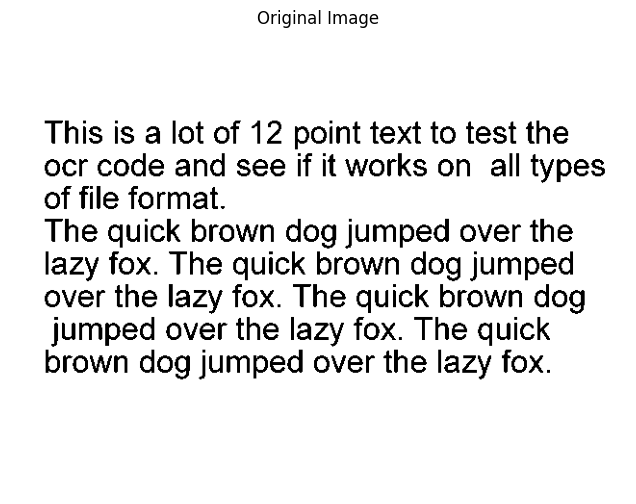

In [3]:
plt.figure(figsize=(10, 6))
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")
plt.show()

## 5. Resize Image if Needed
This step reduces very large images to make OCR faster and prevent the notebook from freezing.

In [4]:
# Resize image if it is too large
image = cv2.imread(image_path)

# Change width if needed
max_width = 1000

height, width = image.shape[:2]

if width > max_width:
    ratio = max_width / width
    new_height = int(height * ratio)
    image = cv2.resize(image, (max_width, new_height))

print("Image loaded and resized successfully.")

Image loaded and resized successfully.


## 6. Convert to Grayscale

Grayscale removes color and keeps only light intensity, which makes the text easier for OCR to read.

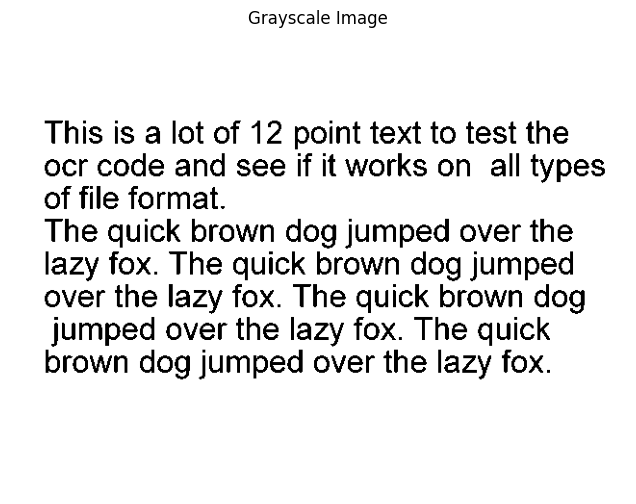

In [5]:
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(10, 6))
plt.imshow(gray_image, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")
plt.show()

## 7. Apply Gaussian Blur

Gaussian blur reduces small noise in the image before thresholding.

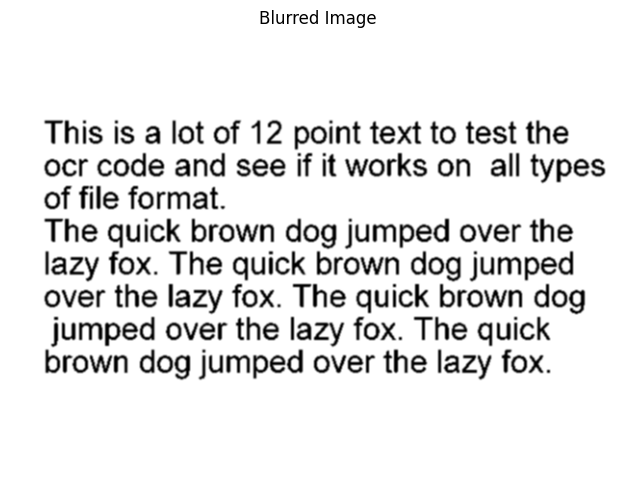

In [6]:
# Change the kernel size from (3, 3) to (5, 5) if the image has more noise or is not very clear
blurred_image = cv2.GaussianBlur(gray_image, (3, 3), 0)

plt.figure(figsize=(10, 6))
plt.imshow(blurred_image, cmap="gray")
plt.title("Blurred Image")
plt.axis("off")
plt.show()

## 8. Apply Adaptive Thresholding

Adaptive thresholding converts the image into clear black and white pixels, making text stand out.

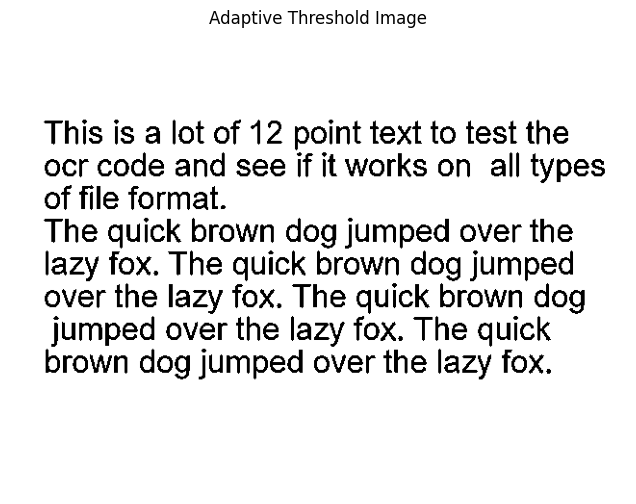

In [7]:
# blockSize controls the size of the local area used for thresholding.
# blockSize  must be an odd number greater than 1, such as 11, 15, or 21.
# C adjusts the threshold strength. Try values like 2, 5, or 10 if the result is unclear.
threshold_image = cv2.adaptiveThreshold(
    blurred_image,
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY,
    11,
    2
)

plt.figure(figsize=(10, 6))
plt.imshow(threshold_image, cmap="gray")
plt.title("Adaptive Threshold Image")
plt.axis("off")
plt.show()

## 9. Extract Text using pytesseract

Now we send the processed image to Tesseract OCR to extract readable text.

In [8]:
# PSM means Page Segmentation Mode.
# You can try:
# --psm 3 for full pages
# --psm 6 for one block of text
# --psm 7 for one single text line
# --psm 11 for scattered text

custom_config = r"--oem 3 --psm 6"

extracted_text = pytesseract.image_to_string(threshold_image, config=custom_config)

print("Extracted Text:")
print("-" * 50)
print(extracted_text)

Extracted Text:
--------------------------------------------------
This is a lot of 12 point text to test the
ocr code and see if it works on all types
of file format.

The quick brown dog jumped over the
lazy fox. The quick brown dog jumped
over the lazy fox. The quick brown dog
jumped over the lazy fox. The quick
brown dog jumped over the lazy fox.



## 10. Display Final OCR Result

This section displays the original image, processed image, and extracted text together.

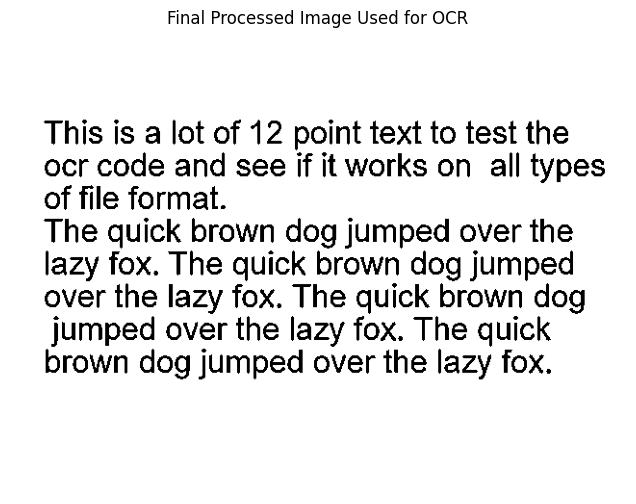

Final OCR Output:
--------------------------------------------------
This is a lot of 12 point text to test the
ocr code and see if it works on all types
of file format.

The quick brown dog jumped over the
lazy fox. The quick brown dog jumped
over the lazy fox. The quick brown dog
jumped over the lazy fox. The quick
brown dog jumped over the lazy fox.


In [9]:
plt.figure(figsize=(10, 6))
plt.imshow(threshold_image, cmap="gray")
plt.title("Final Processed Image Used for OCR")
plt.axis("off")
plt.show()

print("Final OCR Output:")
print("-" * 50)
print(extracted_text.strip())

## 11. OCR Confidence / Accuracy Check

Tesseract can return confidence values for detected words. Higher confidence means the OCR result is more reliable.

In [10]:
# image_to_data gives detailed OCR results including word-level confidence scores
ocr_data = pytesseract.image_to_data(
    threshold_image,
    config=custom_config,
    output_type=pytesseract.Output.DATAFRAME
)

# Remove empty text rows and invalid confidence values
ocr_data = ocr_data.dropna(subset=["text"])
ocr_data = ocr_data[ocr_data["text"].str.strip() != ""]
ocr_data = ocr_data[ocr_data["conf"] != -1]

# Show detected words with confidence
display(ocr_data[["text", "conf"]].head(20))

if len(ocr_data) > 0:
    average_confidence = ocr_data["conf"].mean()
    print(f"Average OCR Confidence: {average_confidence:.2f}%")

    if average_confidence >= 80:
        print("Result: Good OCR confidence.")
    else:
        print("Result: Confidence is below 80%. Try a clearer image or adjust preprocessing.")
else:
    print("No valid text detected. Try a clearer image or a different PSM mode.")

,text,conf
4,This,96
5,is,96
6,a,96
7,lot,96
8,of,96
9,12,95
10,point,96
11,text,96
12,to,96
13,test,96


Average OCR Confidence: 94.77%
Result: Good OCR confidence.


## 12. Conclusion

This project successfully demonstrates a basic OCR pipeline using Python, OpenCV, and pytesseract.

The system loads an image, preprocesses it, extracts text, displays the final result, and checks OCR confidence.

In [11]:
# Addition: Save the extracted text into a text file
output_file = "ocr_extracted_text.txt"

with open(output_file, "w", encoding="utf-8") as file:
    file.write(extracted_text)

print(f"Extracted text saved to: {output_file}")

Extracted text saved to: ocr_extracted_text.txt
